**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---

*   NOMBRE: Mónica María Ramírez Mejía
*   MATRÍCULA: A01797493

En esta actividad trabajarás con el archivo `heart_disease.csv`, basado en un conjunto de datos sobre pacientes y variables clínicas relacionadas con enfermedades cardíacas, disponible en Kaggle.

Los datos fueron recopilados para analizar la presencia de enfermedades cardíacas en los pacientes y contienen información demográfica, clínica y resultados de pruebas diagnósticas. Los indicadores incluidos son:

* `id`: Identificador único de cada paciente
* `age`: Edad del paciente en años
* `origin`: Lugar de estudio
* `sex`: Masculino / Femenino
* `cp`: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático)
* `trestbps`: Presión arterial en reposo (en mm Hg al ingreso al hospital)
* `chol`: Colesterol sérico en mg/dl
* `fbs`: Si el azúcar en ayunas > 120 mg/dl
* `restecg`: Resultados del electrocardiograma en reposo (normal, anomalía ST-T, hipertrofia ventricular izquierda)
* `thalach`: Frecuencia cardíaca máxima alcanzada
* `exang`: Angina inducida por ejercicio (Verdadero / Falso)
* `oldpeak`: Depresión del segmento ST inducida por ejercicio respecto al reposo
* `slope`: Pendiente del segmento ST en el pico de ejercicio
* `ca`: Número de vasos principales coloreados por fluoroscopía (0 - 3)
* `thal`: Resultado de la prueba de perfusión cardíaca (normal, defecto fijo, defecto reversible)
* `num`: Indica si el paciente tiene o no enfermedad cardíaca, o el grado de enfermedad (0 = sano, 1 - 4 = enfermedad) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [658]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer

1. Descarga el archivo: `heart_disease.csv` y guarda, en un dataframe (`cardio_df`), todos sus registros.
* Haz que la columna `id` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.

In [659]:
from google.colab import drive
drive.mount('/content/drive')
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/Ciencia y Analitica de Datos/Tareas/Semana5"
os.chdir(DIR)
cardio_df = pd.read_csv('heart_disease.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [660]:
cardio_df.head(3)

,id,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1


In [661]:
cardio_df.set_index('id', inplace=True)

In [662]:
cardio_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   origin    918 non-null    object 
 3   cp        918 non-null    object 
 4   trestbps  859 non-null    float64
 5   chol      888 non-null    float64
 6   fbs       829 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    863 non-null    float64
 9   exang     863 non-null    object 
 10  oldpeak   856 non-null    float64
 11  slope     610 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       918 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 114.8+ KB


Númericas: 7, Texto: 8

In [663]:
cardio_df.nunique()

,0
age,50
sex,2
origin,4
cp,4
trestbps,60
chol,216
fbs,2
restecg,3
thalch,119
exang,2


2. Examina las variables numéricas que presentan pocos valores únicos, ya que esto puede indicar que en realidad se tratan de variables categóricas codificadas como números.
* Si existen casos de este tipo, conviértelas a categóricas. Antes de hacerlo, revisa sus descripciones para determinar si son ordinales o nominales y, si son ordinales, establece el orden correcto de las categorías.

In [664]:
cardio_df.select_dtypes(include=['number']).columns.tolist()


['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']

ca
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64


<Axes: xlabel='ca'>

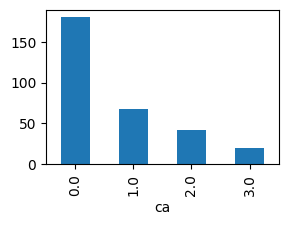

In [665]:
print(cardio_df['ca'].value_counts())
cardio_df['ca'].value_counts().plot(kind='bar', figsize=(3, 2))

In [666]:
cardio_df['ca'] = pd.Categorical(cardio_df['ca'], categories=[0.0, 1.0, 2.0, 3.0], ordered=True)

num
0    411
1    263
2    109
3    107
4     28
Name: count, dtype: int64


<Axes: xlabel='num'>

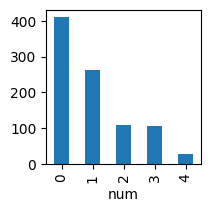

In [667]:
print(cardio_df['num'].value_counts())
cardio_df['num'].value_counts().plot(kind='bar', figsize=(2, 2))

In [668]:
cardio_df['num'] = pd.Categorical(cardio_df['num'], categories=[0, 1, 2, 3, 4], ordered=True)

In [669]:
cardio_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       918 non-null    int64   
 1   sex       918 non-null    object  
 2   origin    918 non-null    object  
 3   cp        918 non-null    object  
 4   trestbps  859 non-null    float64 
 5   chol      888 non-null    float64 
 6   fbs       829 non-null    object  
 7   restecg   918 non-null    object  
 8   thalch    863 non-null    float64 
 9   exang     863 non-null    object  
 10  oldpeak   856 non-null    float64 
 11  slope     610 non-null    object  
 12  ca        309 non-null    category
 13  thal      434 non-null    object  
 14  num       918 non-null    category
dtypes: category(2), float64(4), int64(1), object(8)
memory usage: 102.6+ KB


In [670]:
cardio_df.head(5)

,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
id,,,,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


3. Obtén las estadísticas descriptivas de las variables, realizando el análisis por separado para las variables numéricas y las categóricas.
* Para las numéricas, incluye el sesgo y la curtosis.
* Para las categóricas, imprime además las tablas de frecuencia.

In [671]:
# estadisticas descriptivas variables numericas
num_cols = cardio_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
pd.concat([cardio_df[num_cols].describe().T, cardio_df[num_cols].kurt().rename('curtosis'), cardio_df[num_cols].skew().rename('simetria')], axis=1)

,count,mean,std,min,25%,50%,75%,max,curtosis,simetria
age,918.0,53.530501,9.412783,28.0,47.0,54.0,60.0,77.0,-0.382511,-0.193710
trestbps,859.0,132.294529,18.535875,80.0,120.0,130.0,140.0,200.0,0.632992,0.630411
chol,888.0,242.189189,53.424806,85.0,216.0,223.0,268.0,603.0,6.573848,1.640672
thalch,863.0,137.528389,25.950226,60.0,120.0,140.0,157.0,202.0,-0.483939,-0.209319
oldpeak,856.0,0.880607,1.091840,-2.6,0.0,0.5,1.5,6.2,1.119834,1.037990


In [672]:
cat_cols = cardio_df.select_dtypes(include = ['object', 'category']).columns.tolist()
cardio_df[cat_cols].describe(include = 'object').T


,count,unique,top,freq
sex,918,2,Male,724
origin,918,4,Cleveland,304
cp,918,4,asymptomatic,495
fbs,829,2,False,691
restecg,918,3,normal,551
exang,863,2,False,526
slope,610,3,flat,345
thal,434,3,normal,196


In [673]:
print(pd.concat([cardio_df['sex'].value_counts(dropna=False), cardio_df['sex'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['origin'].value_counts(dropna=False), cardio_df['origin'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['cp'].value_counts(dropna=False), cardio_df['cp'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['fbs'].value_counts(dropna=False), cardio_df['fbs'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['restecg'].value_counts(dropna=False), cardio_df['restecg'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['exang'].value_counts(dropna=False), cardio_df['exang'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['slope'].value_counts(dropna=False), cardio_df['slope'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['ca'].value_counts(dropna=False), cardio_df['ca'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['thal'].value_counts(dropna=False), cardio_df['thal'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))
print("\n" + "-"*40)
print(pd.concat([cardio_df['num'].value_counts(dropna=False), cardio_df['num'].value_counts(normalize=True, dropna=False)], axis=1, keys=['Conteo', 'Frecuencia']))

        Conteo  Frecuencia
sex                       
Male       724    0.788671
Female     194    0.211329

----------------------------------------
               Conteo  Frecuencia
origin                           
Cleveland         304    0.331155
Hungary           292    0.318083
VA Long Beach     200    0.217865
Switzerland       122    0.132898

----------------------------------------
                 Conteo  Frecuencia
cp                                 
asymptomatic        495    0.539216
non-anginal         204    0.222222
atypical angina     174    0.189542
typical angina       45    0.049020

----------------------------------------
       Conteo  Frecuencia
fbs                      
False     691    0.752723
True      138    0.150327
NaN        89    0.096950

----------------------------------------
                  Conteo  Frecuencia
restecg                             
normal               551    0.600218
lv hypertrophy       188    0.204793
st-t abnormality     179  

4. Calcula el porcentaje de valores faltantes en cada columna.
* Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
* Crea un mapa de calor que visualice la distribución de los valores faltantes en todas las columnas restantes.
* Algunas variables presentan valores faltantes de manera simultánea; es decir, en el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo. Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.

In [674]:
(cardio_df.isnull().sum() / len(cardio_df) * 100).sort_values(ascending=False)

,0
ca,66.339869
thal,52.723312
slope,33.551198
fbs,9.694989
oldpeak,6.753813
trestbps,6.427015
thalch,5.991285
exang,5.991285
chol,3.267974
sex,0.000000


In [675]:
cardio_df.drop(columns = ['ca', 'thal', 'slope'], inplace= True)
cardio_df.head(5)

,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
id,,,,,,,,,,,,
1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,0
2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,2
3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,1
4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,0
5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,0


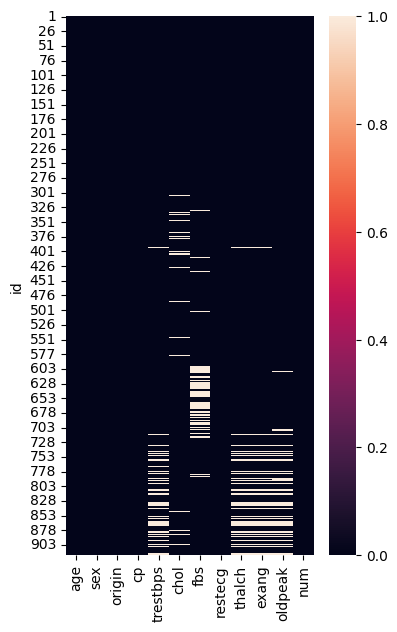

In [676]:
plt.figure(figsize=(4,7))
sns.heatmap(cardio_df.isna())
plt.show()

Las variables son: trestbps, thalch, exang, oldpeak. En las dos primeras, no es normal un valor nulo. En el caso de 'exang', un valor nulo podría ser normal dada la naturaleza y descripcion de la variable, es decir, la persona no presentó la condición. Por último, en el caso de 'oldpeak' un valor nulo se consideraría normal debido a que no todos los pacientes presentarán esta condición.


(https://www.genfar.com/te-cuidamos/cuales-son-los-valores-normales-de-la-presion-arterial/)
(https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates)
(https://www.msdmanuals.com/es/professional/trastornos-cardiovasculares/enfermedad-coronaria/angina-de-pecho)
(https://www.droracle.ai/articles/28617/diagnostic-criteria-for-positive-exercise-stress-test)


5. Si centramos el análisis en una de las variables identificadas en el ejercicio anterior, se puede suponer que los hallazgos obtenidos podrían ser aplicables a las demás variables que presentan un patrón similar.

* ¿Tendrán los valores faltantes de `thalch` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
  *   Numéricas: `age`, `chol`
  *   Categóricas: `restecg`, `cp`

Para ello deberás dividir cada columna en dos grupos: con / sin faltantes en `thalch` y utilizar métodos gráficos y pruebas de hipótesis para ver si hay diferencias significativas.
* Incluye las conclusiones del análisis con los resultados obtenidos.
* Justifica si el mecanismo de faltantes de `thalch` es MCAR (*Missing Completely at Random*) o MAR (*Missing at Random*).

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

In [677]:
BM_MV = cardio_df.thalch.isna()
MV_labels = ['With Missing Values','Without Missing Values']
BM_MV

,thalch
id,
1,False
2,False
3,False
4,False
5,False
...,...
916,False
917,True
918,False


In [678]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for age:


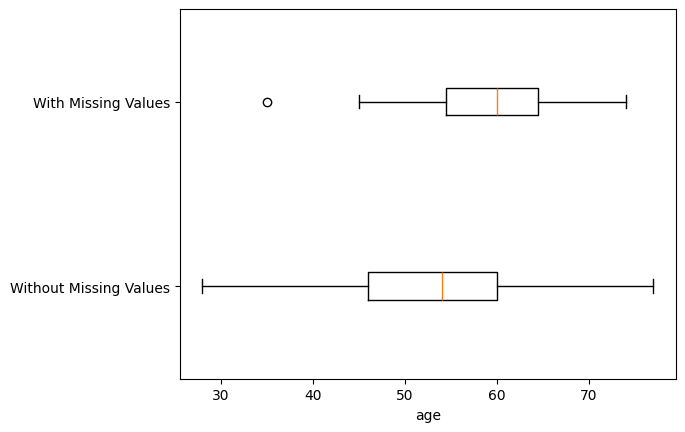

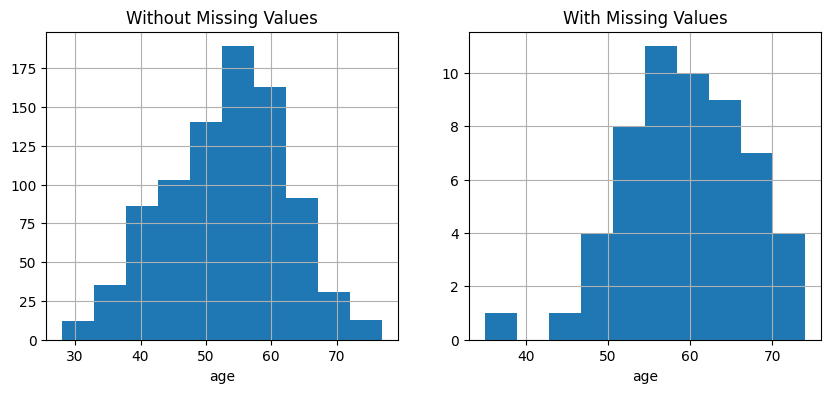

p-value of t-test: 1.5041244185890902e-06

- - - - - - - - - - - - divider - - - - - - - - - - - 

Diagnosis Analysis of Missing Values for chol:


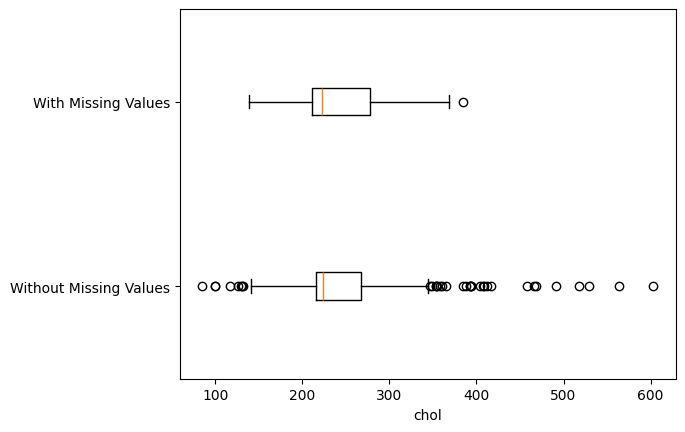

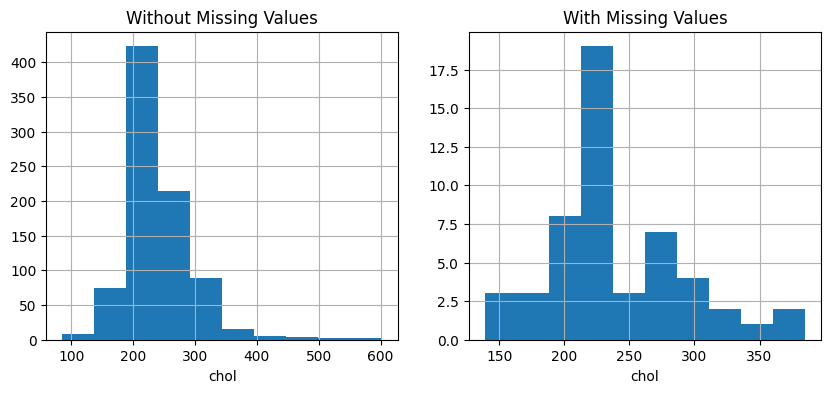

p-value of t-test: 0.7165289974295672

- - - - - - - - - - - - divider - - - - - - - - - - - 



In [679]:
numerical_attributes = ['age', 'chol']
BM_MV = cardio_df.thalch.isna()
for att in numerical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Numerical(cardio_df,att,BM_MV)
    print('\n' + '- - - - - - - - - - - - divider - - - - - - - - - - - '+ '\n')

In [680]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV,df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {}'.format(p_value))

Diagnosis Analysis of Missing Values for restecg:


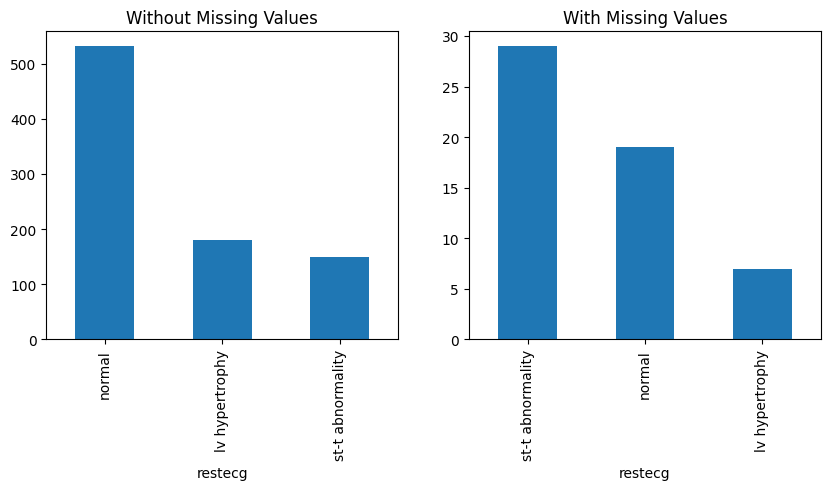

p-value of Chi_squared test: 1.1472889573985467e-09

- - - - - - - - - - - - divider - - - - - - - - - - - 

Diagnosis Analysis of Missing Values for cp:


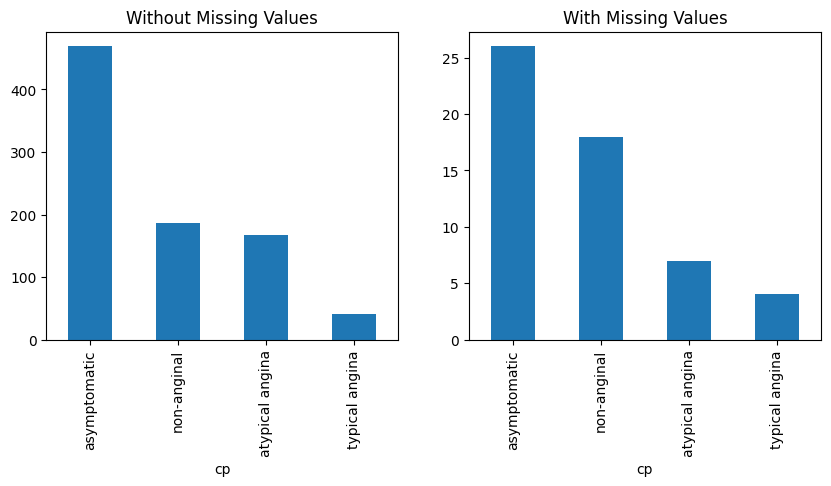

p-value of Chi_squared test: 0.15420097177251701

- - - - - - - - - - - - divider - - - - - - - - - - - 



In [681]:
categorical_attributes = ['restecg', 'cp']
BM_MV = cardio_df.thalch.isna()
for att in categorical_attributes:
    print('Diagnosis Analysis of Missing Values for {}:'.format(att))
    Diagnose_MV_Categorical(cardio_df,att,BM_MV)
    print('\n' + '- - - - - - - - - - - - divider - - - - - - - - - - - '+ '\n')

**Al ver los resultados gráficos y los p-value de chol (0.7165289974295672) y cp (0.15420097177251701) que son mayores a 0.05, podría concluirse que la variable 'thalch' es del tipo MCAR. Sin embargo, al analizar la misma variable respecto a 'age' y 'restecg' podemos ver que sus p-value (1.5041244185890902e-06 y 1.1472889573985467e-09, respectivamente) son menores a 0.05, por lo que, 'thalch' se comporta del tipo MAR. En conclusión, la variable 'thalch' y las otras que se comportan de la misma manera, deberán ser tratadas como MAR para evitar sesgos y errores de análisis y procesamiento.**


6. La imputación de una variable con valores faltantes puede realizarse por grupos o segmentos relevantes. Esto significa que, en lugar de utilizar una estadística global de toda la columna, se calcula la estadística correspondiente dentro de cada grupo definido por otra variable, haciendo:

> `df['var_with_missing'] = df.groupby('related_var')['var_with_missing'].transform(lambda x: x.fillna(x.median()))`

* Utiliza la variable `restecg` para separar los grupos e imputar `thalch` y todas las variables con patrón de faltantes similar (identificadas en el ejercicio 3) Asegúrate de cambiar la función de agregado si hay variables no numéricas.
* Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.

In [682]:
cardio_df['thalch'] = cardio_df.groupby('restecg')['thalch'].transform(lambda x: x.fillna(x.median()))

In [683]:
cardio_df['trestbps'] = cardio_df.groupby('restecg')['trestbps'].transform(lambda x: x.fillna(x.median()))

In [684]:
cardio_df['oldpeak'] = cardio_df.groupby('restecg')['oldpeak'].transform(lambda x: x.fillna(x.median()))

In [685]:
cardio_df['exang'] = cardio_df.groupby('restecg')['exang'].transform(lambda x: x.fillna(x.mode()[0]))

/tmp/ipython-input-1303397023.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cardio_df['exang'] = cardio_df.groupby('restecg')['exang'].transform(lambda x: x.fillna(x.mode()[0]))


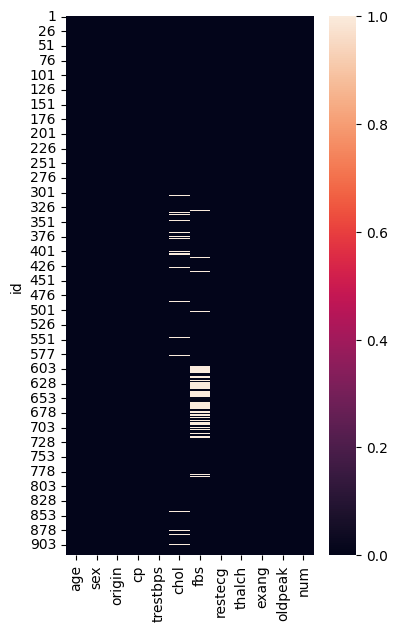

In [686]:
plt.figure(figsize=(4,7))
sns.heatmap(cardio_df.isna())
plt.show()

7. Para las variables que aún presentan valores faltantes, realiza la imputación utilizando estadísticas generales calculadas sobre toda la columna, sin segmentar por grupos. Esta vez utiliza la clase `SimpleImputer` de sklearn
* Justifica la estrategia (*mean, median, most_frequent*) que emplees en cada caso.


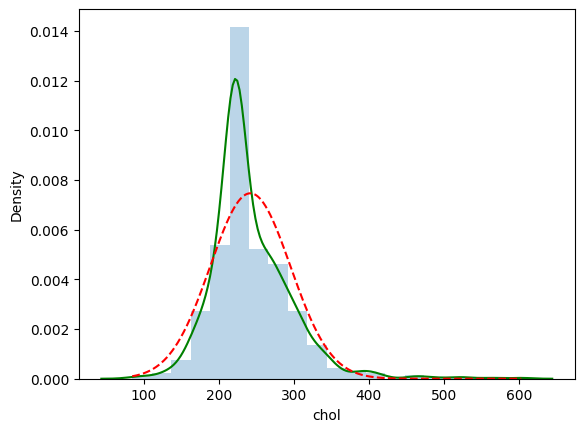

In [687]:
from scipy.stats import norm
plt.hist(cardio_df['chol'], bins=20, density= True, alpha= 0.3)
sns.kdeplot(x=cardio_df['chol'], color='green')

x_vals = np.linspace(cardio_df['chol'].min(), cardio_df['chol'].max(), 1000)
normal_ref = norm.pdf(x_vals, loc= cardio_df['chol'].mean(), scale= cardio_df['chol'].std())
plt.plot(x_vals, normal_ref, color='red', linestyle='--')

In [688]:
# por la forma de la curva de la variable chol (asimetrica), se usa la mediana como metodo de imputacion
cardio_df[['chol']] = SimpleImputer(strategy='median').fit_transform(cardio_df[['chol']])

<BarContainer object of 2 artists>

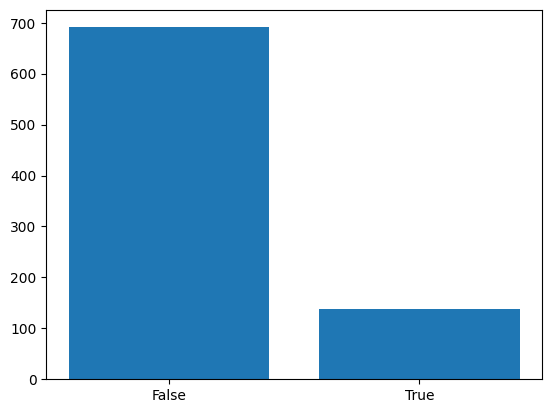

In [689]:
counts = cardio_df['fbs'].value_counts()
plt.bar(counts.index.astype(str), counts.values)

In [690]:
# dada la naturaleza de la variable usaré la moda para la imputacion
cardio_df[['fbs']] = SimpleImputer(strategy='most_frequent').fit_transform(cardio_df[['fbs']])

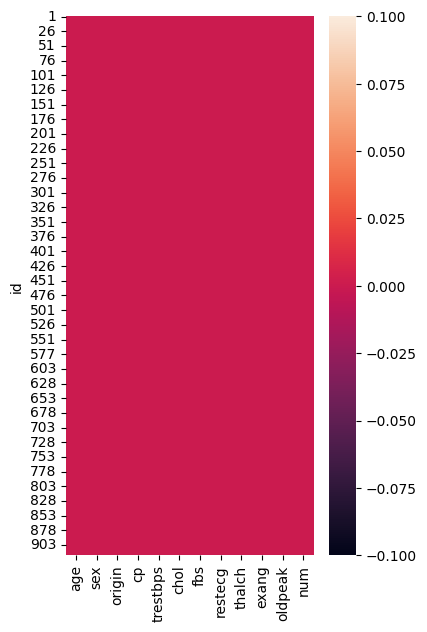

In [691]:
plt.figure(figsize=(4,7))
sns.heatmap(cardio_df.isna())
plt.show()

8. Dibuja boxplots de todas las variables numéricas.
* Obtén los valores atípicos mediante el método gráfico, a partir del objeto devuelto por el boxplot.

In [692]:
num_cols = cardio_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
num_cols

['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

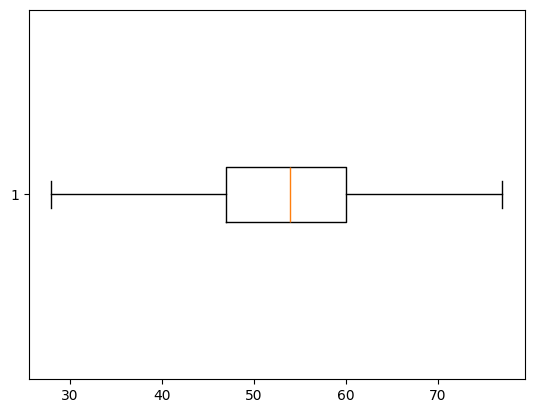

In [693]:
fig = plt.boxplot(cardio_df.age.dropna(), vert=False)

In [694]:
fig['fliers'][0].get_data()

(array([], dtype=int64), array([], dtype=float64))

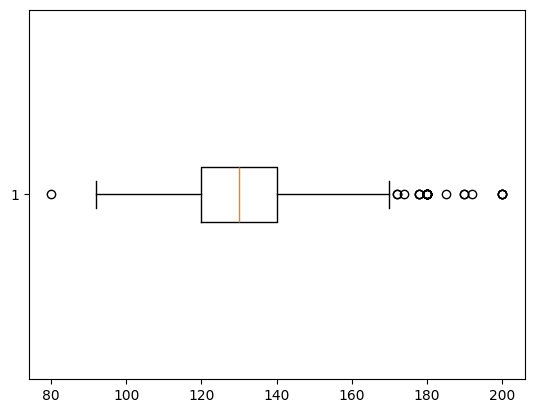

In [695]:
fig = plt.boxplot(cardio_df.trestbps.dropna(), vert=False)

In [696]:
fig['fliers'][0].get_data()

(array([ 80., 172., 180., 200., 174., 178., 192., 180., 178., 180., 190.,
        180., 180., 180., 180., 200., 180., 180., 180., 200., 185., 200.,
        180., 178., 172., 180., 190.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

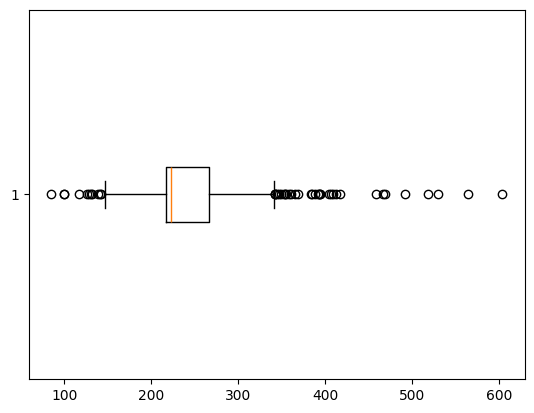

In [697]:
fig = plt.boxplot(cardio_df.chol.dropna(), vert=False)

In [698]:
fig['fliers'][0].get_data()

(array([141., 126., 131., 132., 129., 100.,  85., 117., 100., 142., 139.,
        354., 353., 417., 360., 407., 564., 394., 409., 342., 358., 412.,
        468., 365., 344., 394., 347., 466., 529., 392., 355., 603., 342.,
        404., 518., 388., 491., 342., 393., 458., 384., 349., 369., 385.]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

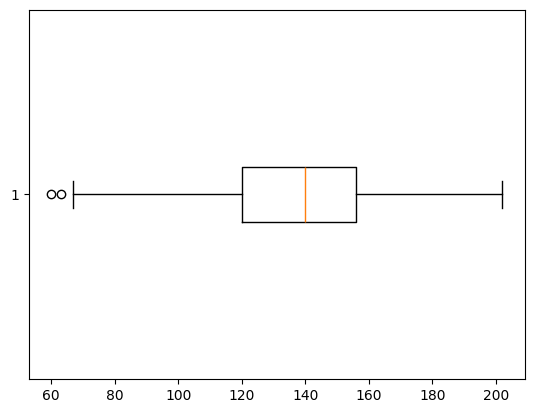

In [699]:
fig = plt.boxplot(cardio_df.thalch.dropna(), vert=False)

In [700]:
fig['fliers'][0].get_data()

(array([60., 63.]), array([1., 1.]))

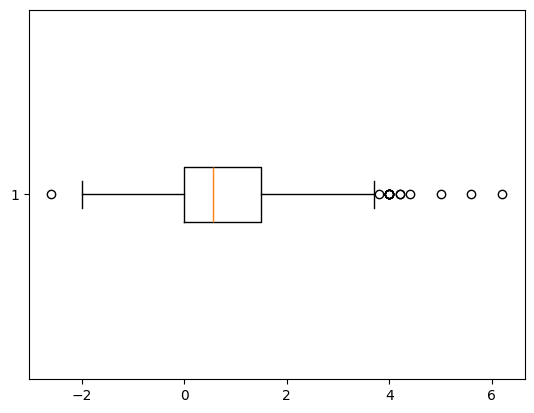

In [701]:
fig = plt.boxplot(cardio_df.oldpeak.dropna(), vert=False)

In [702]:
fig['fliers'][0].get_data()

(array([-2.6,  6.2,  4. ,  5.6,  4. ,  4.2,  4.2,  3.8,  4.4,  4. ,  4. ,
         5. ,  4. ,  4. ,  4. ,  4. ]),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]))

9. Para la variable `trestbps`, calcula los valores atípicos utilizando el método del rango intercuartílico (IQR).
* Para ello obtén los cuartiles necesarios y determina los límites superior e inferior para filtrar los valores que se encuentren fuera de ese rango.
* Verifica si los resultados coinciden con los obtenidos en el ejercicio anterior.

In [703]:
Q1 = cardio_df.trestbps.quantile(0.25)
Q3 = cardio_df.trestbps.quantile(0.75)
IQR = Q3-Q1

BM = (cardio_df.trestbps > (Q3+1.5 *IQR)) | (cardio_df.trestbps < (Q1-1.5 *IQR))
cardio_df[BM]

,age,sex,origin,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,num
id,,,,,,,,,,,,
15,52,Male,Cleveland,non-anginal,172.0,199.0,True,normal,162.0,False,0.5,0
84,68,Male,Cleveland,non-anginal,180.0,274.0,True,lv hypertrophy,150.0,True,1.6,3
127,56,Female,Cleveland,asymptomatic,200.0,288.0,True,lv hypertrophy,133.0,True,4.0,3
173,59,Female,Cleveland,asymptomatic,174.0,249.0,False,normal,143.0,True,0.0,1
184,59,Male,Cleveland,typical angina,178.0,270.0,False,lv hypertrophy,145.0,False,4.2,0
189,54,Male,Cleveland,atypical angina,192.0,283.0,False,lv hypertrophy,195.0,False,0.0,1
202,64,Female,Cleveland,asymptomatic,180.0,325.0,False,normal,154.0,True,0.0,0
214,66,Female,Cleveland,asymptomatic,178.0,228.0,True,normal,165.0,True,1.0,3
232,55,Female,Cleveland,asymptomatic,180.0,327.0,False,st-t abnormality,117.0,True,3.4,2


Los resultados obtenidos coinciden con el gráfico boxplot.

10. Elimina los valores atípicos identificados de la variable `trestbps`.
* Dibuja el boxplot final para visualizar la distribución depurada.

In [704]:
Q3 = cardio_df.trestbps.quantile(0.75)
Q1 = cardio_df.trestbps.quantile(0.25)
IQR = Q3 - Q1
lower_cap = Q1-IQR*1.5
upper_cap = Q3+IQR*1.5
BM = cardio_df.trestbps < lower_cap
cardio_df.loc[cardio_df[BM].index,'trestbps'] = lower_cap
BM = cardio_df.trestbps > upper_cap
cardio_df.loc[cardio_df[BM].index,'trestbps'] = upper_cap

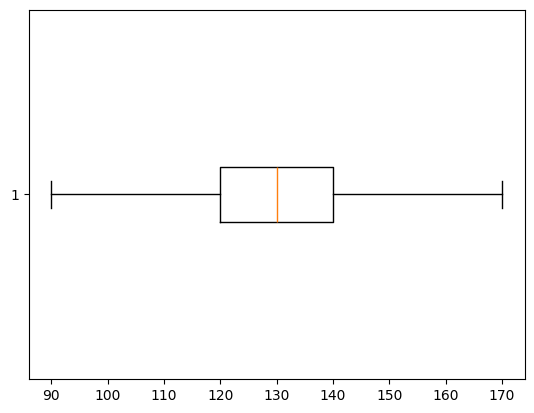

In [705]:
fig = plt.boxplot(cardio_df.trestbps.dropna(), vert=False)